# Skin Cancer Detection using HAM10000 Dataset

This notebook demonstrates a simple machine learning approach (using a Convolutional Neural Network) to detect skin cancer from images.

In [3]:
pip uninstall psutil -y


Found existing installation: psutil 5.6.3
Uninstalling psutil-5.6.3:
  Successfully uninstalled psutil-5.6.3
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install psutil==5.9.5

   -------------------------------------- 255.1/255.1 kB 920.7 kB/s eta 0:00:00
  Attempting uninstall: psutil
    Found existing installation: psutil 7.2.2
    Uninstalling psutil-7.2.2:
      Successfully uninstalled psutil-7.2.2
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
spyder 3.3.6 requires pyqt5<5.13; python_version >= "3", which is not installed.
spyder 3.3.6 requires pyqtwebengine<5.13; python_version >= "3", which is not installed.


In [ ]:
# # !kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 --unzip -p ./ham10000

In [1]:
pip install -r requirements.txt

  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached numpy-1.21.6-cp37-cp37m-win_amd64.whl.metadata (2.2 kB)
  Using cached requests_oauthlib-2.0.0-py2.py3-none-any.whl.metadata (11 kB)
  Using cached importlib_metadata-6.7.0-py3-none-any.whl.metadata (4.9 kB)
   ---------------------------------------- 266.3/266.3 MB 1.0 MB/s eta 0:00:00
Using cached numpy-1.21.6-cp37-cp37m-win_amd64.whl (14.0 MB)
   ---------------------------------------- 896.6/896.6 kB 1.1 MB/s eta 0:00:00
   -------------------------------------- 133.7/133.7 kB 987.7 kB/s eta 0:00:00
Using cached astunparse-1.6.3-py2.py3-none-any.whl (12 kB)
Using cached flatbuffers-25.12.19-py2.py3-none-any.whl (26 kB)
Using cached google_pasta-0.2.0-py3-none-any.whl (57 kB)
   

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
spyder 3.3.6 requires pyqt5<5.13; python_version >= "3", which is not installed.
spyder 3.3.6 requires pyqtwebengine<5.13; python_version >= "3", which is not installed.


In [23]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
import kaggle

## 1. Download and Extract the Dataset
Ensure you have your `kaggle.json` configured as per the README.

In [24]:
# dataset_slug = 'kmader/skin-cancer-mnist-ham10000'
download_path = '.'

# Download dataset
# # print('Downloading dataset...')
# # kaggle.api.dataset_download_cli(dataset_slug, path=download_path, unzip=True)
# # print('Download and extraction complete!')

## 2. Data Loading and Preprocessing
We will read the metadata to map image files to their classes. To keep memory usage low for this simple project, we will resize images to a smaller dimension (e.g., 64x64).

In [25]:
download_path = '.'
# Read metadata
metadata_path = 'HAM10000_metadata.csv'
metadata = pd.read_csv(metadata_path)

# The dataset extracts multiple folders and files. Let's find all image paths.
image_paths = {}
for root, dirs, files in os.walk(download_path):
    for file in files:
        if file.endswith('.jpg'):
            image_id = file.split('.')[0]
            image_paths[image_id] = os.path.join(root, file)

metadata['path'] = metadata['image_id'].map(image_paths)
mapping = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}
metadata['cell_type'] = metadata['dx'].map(mapping)
metadata['label'] = pd.Categorical(metadata['dx']).codes

print(metadata.head())

     lesion_id      image_id   dx dx_type   age   sex localization  \
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp   
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp   
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp   
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp   
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear   

                                        path                      cell_type  \
0  .\HAM10000_images_part_1\ISIC_0027419.jpg  Benign keratosis-like lesions   
1  .\HAM10000_images_part_1\ISIC_0025030.jpg  Benign keratosis-like lesions   
2  .\HAM10000_images_part_1\ISIC_0026769.jpg  Benign keratosis-like lesions   
3  .\HAM10000_images_part_1\ISIC_0025661.jpg  Benign keratosis-like lesions   
4  .\HAM10000_images_part_2\ISIC_0031633.jpg  Benign keratosis-like lesions   

   label  
0      2  
1      2  
2      2  
3      2  
4      2  


In [26]:
from tqdm import tqdm
tqdm.pandas()

IMG_SIZE = 128

def load_and_resize(path):
    img = Image.open(path).resize((IMG_SIZE, IMG_SIZE))
    return np.array(img)

print('Loading images. This might take a minute...')
# Drop NA paths to avoid errors if any files are missing
metadata = metadata.dropna(subset=['path'])
metadata['image'] = metadata['path'].progress_map(load_and_resize)

X = np.stack(metadata['image'].values) / 255.0  # Normalize to [0, 1]
y = metadata['label'].values

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

Loading images. This might take a minute...


100%|████████████████████████████████████████████████████████████████████████████| 10015/10015 [04:07<00:00, 40.48it/s]


X shape: (10015, 128, 128, 3)
y shape: (10015,)


In [27]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Data split into training and testing sets.')

Data split into training and testing sets.


## 3. Building the Artificial Neural Network (CNN)
For images, a basic Convolutional Neural Network performs much better than a simple flat ANN.

In [28]:
from tensorflow.keras.layers.experimental.preprocessing import RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.layers import BatchNormalization

num_classes = len(metadata['dx'].unique())

model = Sequential([
    # Step 1: Data Augmentation Layer
    RandomFlip('horizontal_and_vertical', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    RandomRotation(0.2),
    RandomZoom(0.2),
    
    # Step 2: Simple CNN (3 Layers)
    Conv2D(32, (3, 3), activation='relu'),
    BatchNormalization(),
    
    MaxPooling2D((2, 2)),
    
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    # Step 3: Head
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 random_flip (RandomFlip)    (None, 128, 128, 3)       0         
                                                                 
 random_rotation (RandomRota  (None, 128, 128, 3)      0         
 tion)                                                           
                                                                 
 random_zoom (RandomZoom)    (None, 128, 128, 3)       0         
                                                                 
 conv2d_2 (Conv2D)           (None, 126, 126, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 126, 126, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 63, 63, 32)      

## 4. Train the Model

In [ ]:
from sklearn.utils import class_weight
import numpy as np

print('Calculating class weights...')
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
dict_weights = dict(enumerate(weights))

print('Training the upgraded model with data augmentation...')
history = model.fit(
    X_train, y_train, 
    epochs=20, 
    validation_split=0.2, 
    batch_size=32, 
    class_weight=dict_weights
)


Calculating class weights...
Training the upgraded model with data augmentation...
Epoch 1/20
201/201 [==============================] - 237s 1s/step - loss: 10.6065 - accuracy: 0.3015 - val_loss: 2.2937 - val_accuracy: 0.0193
Epoch 2/20
201/201 [==============================] - 148s 738ms/step - loss: 5.1783 - accuracy: 0.2456 - val_loss: 3.0085 - val_accuracy: 0.0774
Epoch 3/20
201/201 [==============================] - 136s 677ms/step - loss: 3.4603 - accuracy: 0.2731 - val_loss: 2.0694 - val_accuracy: 0.2820
Epoch 4/20
201/201 [==============================] - 180s 898ms/step - loss: 2.6507 - accuracy: 0.3088 - val_loss: 2.1436 - val_accuracy: 0.2776
Epoch 5/20
201/201 [==============================] - 139s 693ms/step - loss: 2.2937 - accuracy: 0.2999 - val_loss: 3.8585 - val_accuracy: 0.1054
Epoch 6/20
201/201 [==============================] - 133s 663ms/step - loss: 2.0237 - accuracy: 0.2745 - val_loss: 1.7601 - val_accuracy: 0.3038
Epoch 7/20
201/201 [=======================

## 5. Evaluation

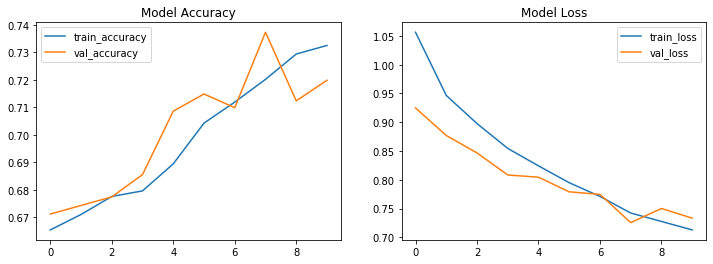

In [21]:
plt.figure(figsize=(12, 4))
# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Model Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Model Loss')
plt.legend()
plt.show()

In [22]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'\nTest accuracy: {test_acc:.4f}')

63/63 [==============================] - 2s 37ms/step - loss: 0.7658 - accuracy: 0.7169

Test accuracy: 0.7169
